In [17]:
!pip install torch scikit-learn pandas numpy matplotlib seaborn -q
print("✓ Libraries installed successfully!")


✓ Libraries installed successfully!


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")


✓ All libraries imported successfully!
PyTorch version: 2.8.0+cpu


In [19]:
# Load dataset
df = pd.read_csv('D:\Sem 7\Final Year Project\Smarfin models\Model 5\PFT_dataset.csv')

print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nBasic Statistics:\n{df.describe()}")


DATASET OVERVIEW

Dataset Shape: (3000, 25)

First 5 rows:
         date  user_id  monthly_income  monthly_expense_total  savings_rate  \
0  2019-01-01     1584         3119.58                3212.07          0.38   
1  2019-01-31     1045         3262.44                3732.81          0.10   
2  2019-03-02     1756         2931.20                3335.58          0.15   
3  2019-04-01     1724         3506.79                2327.59          0.17   
4  2019-05-01     1600         4606.87                2182.58          0.34   

   budget_goal financial_scenario  credit_score  debt_to_income_ratio  \
0      3676.11          inflation         721.0                  0.56   
1      2607.17          inflation         670.0                  0.42   
2      3004.14          inflation         691.0                  0.24   
3      3346.97             normal         717.0                  0.16   
4      2670.09          inflation         795.0                  0.25   

   loan_payment  ...  discr

In [20]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort by user_id and date
df = df.sort_values(['user_id', 'date']).reset_index(drop=True)

# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['day_of_year'] = df['date'].dt.dayofyear

print("✓ Date preprocessing completed!")
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"Number of unique users: {df['user_id'].nunique()}")


✓ Date preprocessing completed!

Date range: 2019-01-01 00:00:00 to 2023-11-06 00:00:00
Number of unique users: 944


In [21]:
# Encode categorical variables
categorical_columns = ['financial_scenario', 'income_type', 'category', 
                       'cash_flow_status', 'financial_stress_level']

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("✓ Categorical encoding completed!")
print(f"Encoded columns: {[col + '_encoded' for col in categorical_columns]}")


✓ Categorical encoding completed!
Encoded columns: ['financial_scenario_encoded', 'income_type_encoded', 'category_encoded', 'cash_flow_status_encoded', 'financial_stress_level_encoded']


In [22]:
# Create financial features
df['net_cash_flow'] = df['monthly_income'] - df['monthly_expense_total']
df['expense_to_income_ratio'] = df['monthly_expense_total'] / (df['monthly_income'] + 1)
df['savings_potential'] = df['monthly_income'] - df['essential_spending']
df['discretionary_ratio'] = df['discretionary_spending'] / (df['monthly_expense_total'] + 1)
df['budget_adherence'] = df['monthly_expense_total'] / (df['budget_goal'] + 1)
df['debt_burden'] = df['loan_payment'] + df['rent_or_mortgage']
df['emergency_fund_months'] = df['emergency_fund'] / (df['monthly_expense_total'] + 1)
df['investment_rate'] = df['investment_amount'] / (df['monthly_income'] + 1)

# Create lag features
lag_features = ['monthly_income', 'monthly_expense_total', 'actual_savings']
for feature in lag_features:
    df[f'{feature}_lag1'] = df.groupby('user_id')[feature].shift(1)

# Fill NaN values
df = df.fillna(method='bfill').fillna(0)

print("✓ Feature engineering completed!")
print(f"Total features: {df.shape[1]}")


✓ Feature engineering completed!
Total features: 45


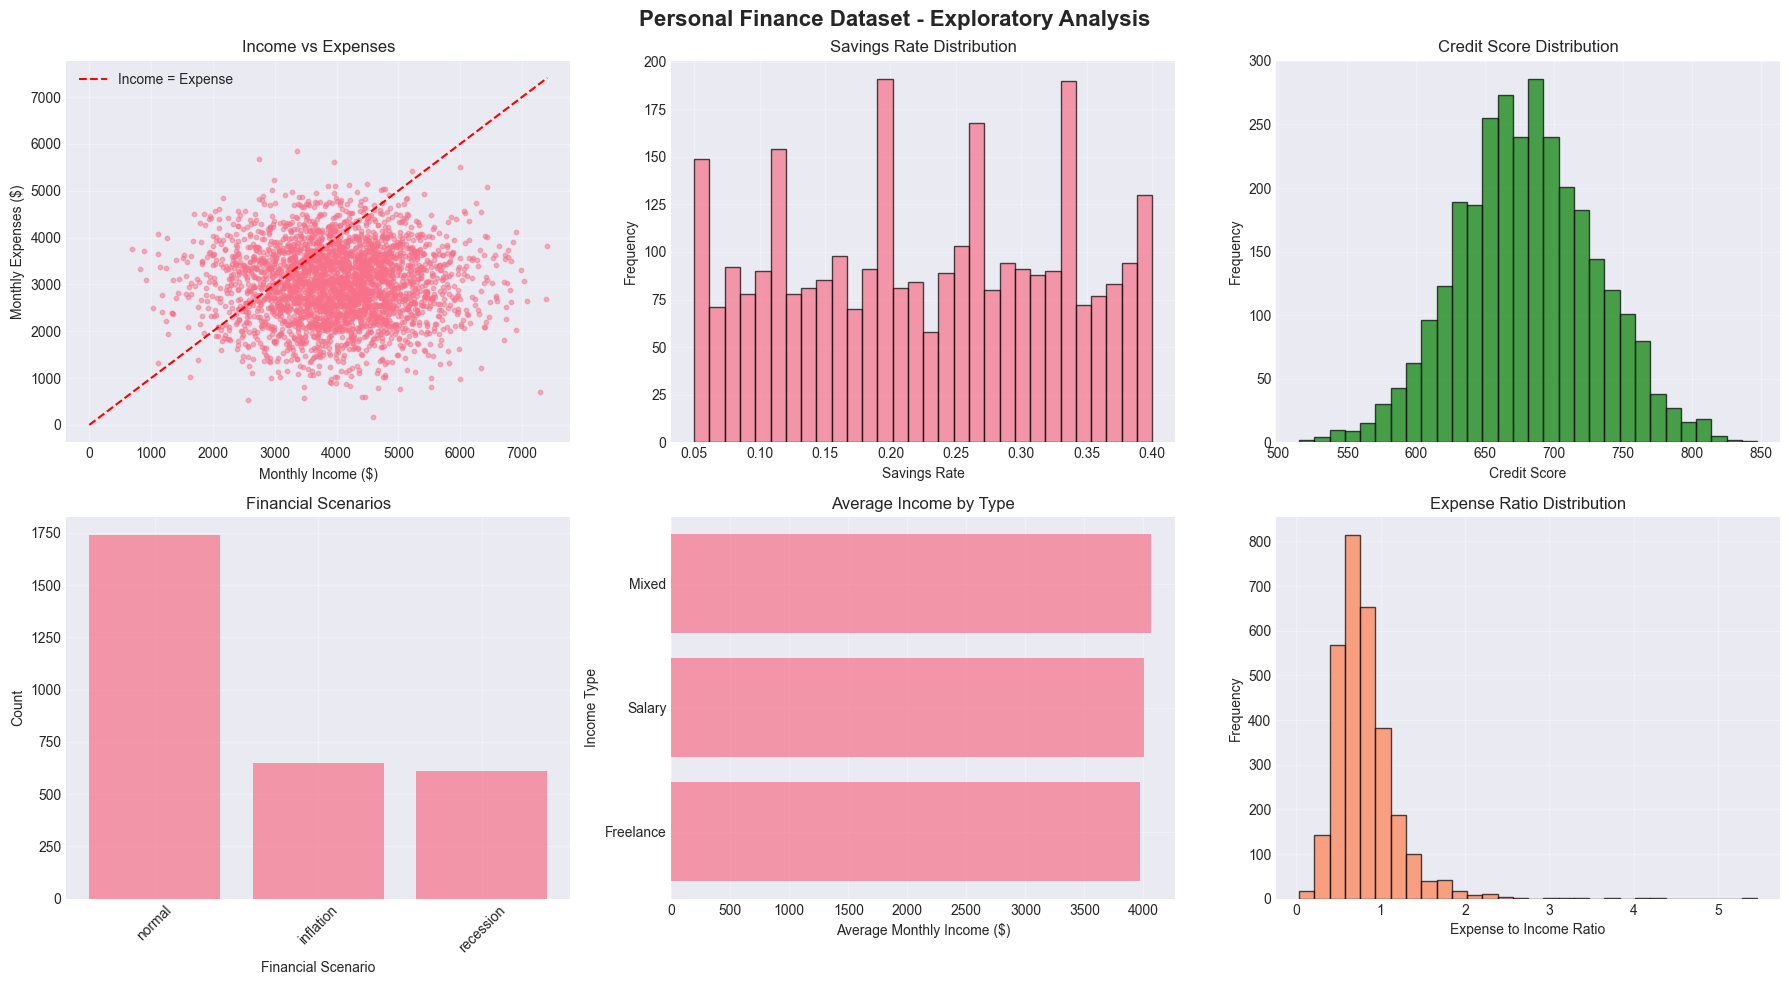

✓ Exploratory visualizations saved!


In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Personal Finance Dataset - Exploratory Analysis', fontsize=16, fontweight='bold')

# Plot 1: Income vs Expenses
axes[0, 0].scatter(df['monthly_income'], df['monthly_expense_total'], alpha=0.5, s=10)
axes[0, 0].plot([0, df['monthly_income'].max()], [0, df['monthly_income'].max()], 'r--', label='Income = Expense')
axes[0, 0].set_xlabel('Monthly Income ($)')
axes[0, 0].set_ylabel('Monthly Expenses ($)')
axes[0, 0].set_title('Income vs Expenses')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Savings Rate Distribution
axes[0, 1].hist(df['savings_rate'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Savings Rate')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Savings Rate Distribution')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Credit Score Distribution
axes[0, 2].hist(df['credit_score'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_xlabel('Credit Score')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Credit Score Distribution')
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Financial Scenario
scenario_counts = df['financial_scenario'].value_counts()
axes[1, 0].bar(scenario_counts.index, scenario_counts.values, alpha=0.7)
axes[1, 0].set_xlabel('Financial Scenario')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Financial Scenarios')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Income by Type
income_by_type = df.groupby('income_type')['monthly_income'].mean().sort_values()
axes[1, 1].barh(income_by_type.index, income_by_type.values, alpha=0.7)
axes[1, 1].set_xlabel('Average Monthly Income ($)')
axes[1, 1].set_ylabel('Income Type')
axes[1, 1].set_title('Average Income by Type')
axes[1, 1].grid(True, alpha=0.3)

# Plot 6: Expense Ratio Distribution
axes[1, 2].hist(df['expense_to_income_ratio'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 2].set_xlabel('Expense to Income Ratio')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Expense Ratio Distribution')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('finance_eda.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Exploratory visualizations saved!")


In [24]:
# Select features for modeling
feature_columns = [
    'credit_score', 'debt_to_income_ratio', 'loan_payment', 'investment_amount',
    'subscription_services', 'emergency_fund', 'transaction_count',
    'discretionary_spending', 'essential_spending', 'rent_or_mortgage',
    'financial_advice_score', 'savings_rate', 'budget_goal',
    'month', 'quarter', 'year',
    'financial_scenario_encoded', 'income_type_encoded', 'category_encoded',
    'cash_flow_status_encoded', 'financial_stress_level_encoded',
    'net_cash_flow', 'expense_to_income_ratio', 'savings_potential',
    'discretionary_ratio', 'budget_adherence', 'debt_burden',
    'emergency_fund_months', 'investment_rate',
    'monthly_income_lag1', 'monthly_expense_total_lag1', 'actual_savings_lag1'
]

target_columns = ['monthly_income', 'monthly_expense_total', 'actual_savings']

X = df[feature_columns].values
y = df[target_columns].values

print(f"✓ Features prepared!")
print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")


✓ Features prepared!
Feature shape: (3000, 32)
Target shape: (3000, 3)


In [25]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print("✓ Data split and scaled!")
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")


✓ Data split and scaled!
Training set: 2400 samples
Test set: 600 samples


In [26]:
class FinanceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create datasets
train_dataset = FinanceDataset(X_train_scaled, y_train_scaled)
test_dataset = FinanceDataset(X_test_scaled, y_test_scaled)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("✓ PyTorch datasets created!")
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


✓ PyTorch datasets created!
Training batches: 75
Test batches: 19


In [27]:
class FinancePredictor(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(FinancePredictor, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.bn2 = nn.BatchNorm1d(hidden_size // 2)
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc3 = nn.Linear(hidden_size // 2, hidden_size // 4)
        self.bn3 = nn.BatchNorm1d(hidden_size // 4)
        self.dropout3 = nn.Dropout(0.1)
        
        self.fc4 = nn.Linear(hidden_size // 4, output_size)
        
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]
hidden_size = 128
output_size = 3  # income, expenses, savings

model = FinancePredictor(input_size, hidden_size, output_size)

print("✓ Model defined!")
print(f"Model architecture:\n{model}")
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


✓ Model defined!
Model architecture:
FinancePredictor(
  (fc1): Linear(in_features=32, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.1, inplace=False)
  (fc4): Linear(in_features=32, out_features=3, bias=True)
  (relu): ReLU()
)

Total parameters: 15,107


In [28]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            total_loss += loss.item()
            all_predictions.append(outputs.cpu().numpy())
            all_targets.append(y_batch.cpu().numpy())
    
    predictions = np.vstack(all_predictions)
    targets = np.vstack(all_targets)
    
    return total_loss / len(test_loader), predictions, targets

print("✓ Training functions defined!")


✓ Training functions defined!


In [29]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Define loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
train_losses = []
val_losses = []

print("="*70)
print("STARTING MODEL TRAINING")
print("="*70)
print(f"Device: {device}")
print(f"Epochs: {epochs}")
print(f"Learning rate: 0.001")
print("="*70)

for epoch in range(epochs):
    train_loss = train_model(model, train_loader, criterion, optimizer, device)
    val_loss, _, _ = evaluate_model(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\n" + "="*70)
print("✓ TRAINING COMPLETED!")
print("="*70)


STARTING MODEL TRAINING
Device: cpu
Epochs: 100
Learning rate: 0.001
Epoch [10/100] - Train Loss: 0.1263, Val Loss: 0.0355
Epoch [20/100] - Train Loss: 0.1043, Val Loss: 0.0195
Epoch [30/100] - Train Loss: 0.0930, Val Loss: 0.0166
Epoch [40/100] - Train Loss: 0.0837, Val Loss: 0.0197
Epoch [50/100] - Train Loss: 0.0845, Val Loss: 0.0106
Epoch [60/100] - Train Loss: 0.0820, Val Loss: 0.0173
Epoch [70/100] - Train Loss: 0.0846, Val Loss: 0.0175
Epoch [80/100] - Train Loss: 0.0773, Val Loss: 0.0137
Epoch [90/100] - Train Loss: 0.0750, Val Loss: 0.0138
Epoch [100/100] - Train Loss: 0.0847, Val Loss: 0.0169

✓ TRAINING COMPLETED!
